# ESS Battery Health — EDA 및 모델 설계

데이터셋: MIT-Stanford Dataset - *Data-driven prediction of battery cycle life*

## 분석 목적
- 초기 100 사이클 데이터를 활용하여 배터리 총 잔여 수명 예측
- Batch 1, Batch 2, Batch 3에 대한 EDA 수행
- 배치 간 Cycle Life, 열화, ΔQ(V), 충전 조건, 초기 신호의 차이 비교
- 각 결과를 `관찰 → 해석 → 질문에 대한 답변`으로 정리
- EDA 결과를 Feature Engineering 및 모델 후보 선정 근거로 연결

## Questions
1. Cycle Life 분포는 어떻게 생겼는가?
2. 방전 용량은 어떻게 감소하며 knee point는 어디인가?
3. Cycle 100 − Cycle 10의 ΔQ(V) 곡선은 수명 차이를 보여주는가?
4. 충전 조건(C-rate)과 수명은 어떤 관계인가?
5. 어떤 초기 신호가 수명과 관련되며 다중공선성은 어떠한가?

## 단계 구분
원본 로딩·품질 확인 → EDA(질문별 탐색용 피처 생성 포함) → 모델 입력 후보 선정 → 타깃 정의·모델링 전략.
탐색용 피처 생성은 곡선·측정값의 관계를 분석하기 위한 준비이며, 모델 입력 후보 선정과 구분한다. 모델 학습·예측·성능 평가는 별도의 `02_Modeling.ipynb` 노트북에서 수행한다.


## 0. 환경 설정

라이브러리는 NumPy, pandas, SciPy, Matplotlib을 사용한다. 원본은 MATLAB v7.3(HDF5) 파일이므로 `h5py`로 필요한 데이터만 읽는다. 파일 전체를 한꺼번에 변환하는 방식보다 메모리 사용량이 작다.

In [1]:
# 필요한 경우 한 번만 실행
# %pip install -q numpy pandas scipy matplotlib h5py ipykernel


In [ ]:
from pathlib import Path

import re
import sys
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings('ignore')
NOTEBOOK_VERSION = 'DAY1-EDA-v2.2-eda-feature-separation'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.grid': True, 'grid.alpha': .25})

print('Python:', sys.version.split()[0])
print('Kernel:', sys.executable)
print('Notebook version:', NOTEBOOK_VERSION)
print('Working directory:', Path.cwd())


Python: 3.11.15
Kernel: /Users/jjy/ds-mini-project/.venv/bin/python
Notebook version: DAY1-EDA-v2.2-eda-feature-separation
Working directory: /Users/jjy/ds-mini-project


## 1. 데이터 파일 확인

작업 폴더에서 세 배치 파일을 확인한다. `2018-04-03_varcharge`는 다른 연구의 충전 최적화 데이터이므로 이번 기본 분석에서는 제외한다.

In [3]:
DATA_DIR = Path.cwd()
BATCH_FILES = {
    'Batch 1': DATA_DIR / '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'Batch 2': DATA_DIR / '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'Batch 3': DATA_DIR / '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

file_table = pd.DataFrame([
    {
        'batch': batch,
        'file': path.name,
        'exists': path.exists(),
        'size_gb': path.stat().st_size / 1024**3 if path.exists() else np.nan,
    }
    for batch, path in BATCH_FILES.items()
])
display(file_table)

if not file_table['exists'].all():
    raise FileNotFoundError('필수 데이터 파일이 작업 폴더에 없습니다.')


,batch,file,exists,size_gb
0,Batch 1,2017-05-12_batchdata_updated_struct_errorcorre...,True,2.8175
1,Batch 2,2018-02-20_batchdata_updated_struct_errorcorre...,True,1.8837
2,Batch 3,2018-04-12_batchdata_updated_struct_errorcorre...,True,3.0144


## 2. 원본 데이터 로딩

- 셀 수준: `cycle_life`, `charging_policy`
- 사이클 요약: `QD`, `QC`, `IR`, `Tmax`, `Tavg`, `Tmin`, `chargetime`
- 사이클 내부 원본: Cycle 10·100의 `Qdlin`과 전압축 `Vdlin`

2~3GB 파일 전체를 변환하지 않고 `h5py`로 필요한 데이터만 읽는다. 이 단계는 원본 배열을 읽고 표로 구성하는 역할만 한다. ΔQ(V) 계산·전압 보간·통계 피처 생성은 Question 3에서 수행한다.


In [4]:
SUMMARY_FIELDS = {
    'cycle': 'cycle',
    'QD': 'QDischarge',
    'QC': 'QCharge',
    'IR': 'IR',
    'Tmax': 'Tmax',
    'Tavg': 'Tavg',
    'Tmin': 'Tmin',
    'chargetime': 'chargetime',
}

def read_reference(h5: h5py.File, reference) -> np.ndarray:
    return np.asarray(h5[reference][()]).squeeze()

def read_text_reference(h5: h5py.File, reference) -> str:
    values = read_reference(h5, reference).reshape(-1)
    return ''.join(chr(int(value)) for value in values if int(value) != 0)



In [5]:
def load_batch(path: Path, batch_name: str):
    summary_parts = []
    cell_rows = []
    raw_qv_data = []
    errors = []

    with h5py.File(path, 'r') as h5:
        batch = h5['batch']
        n_cells = batch['cycle_life'].shape[0]

        for cell_index in range(n_cells):
            cell_id = f'{batch_name.replace(" ", "")}_cell_{cell_index:03d}'
            try:
                cycle_life = float(read_reference(h5, batch['cycle_life'][cell_index, 0]))
                policy = read_text_reference(h5, batch['policy_readable'][cell_index, 0])

                summary_group = h5[batch['summary'][cell_index, 0]]
                arrays = {
                    output: np.asarray(summary_group[source][()]).squeeze().astype(float)
                    for output, source in SUMMARY_FIELDS.items()
                }
                n_cycles = min(len(values) for values in arrays.values())
                part = pd.DataFrame({name: values[:n_cycles] for name, values in arrays.items()})
                part.insert(0, 'charging_policy', policy)
                part.insert(0, 'cycle_life', cycle_life)
                part.insert(0, 'cell_id', cell_id)
                part.insert(0, 'batch', batch_name)
                summary_parts.append(part)

                cell_rows.append({
                    'batch': batch_name, 'cell_id': cell_id,
                    'cycle_life': cycle_life, 'charging_policy': policy,
                    'n_cycles': n_cycles,
                })

                cycles_group = h5[batch['cycles'][cell_index, 0]]
                if cycles_group['Qdlin'].shape[0] < 100:
                    continue
                voltage = read_reference(h5, batch['Vdlin'][cell_index, 0])
                qdlin_10 = read_reference(h5, cycles_group['Qdlin'][9, 0])
                qdlin_100 = read_reference(h5, cycles_group['Qdlin'][99, 0])
                raw_qv_data.append({
                    'batch': batch_name, 'cell_id': cell_id,
                    'cycle_life': cycle_life, 'voltage': voltage,
                    'qdlin_10': qdlin_10, 'qdlin_100': qdlin_100,
                })
            except Exception as error:
                errors.append({'batch': batch_name, 'cell_id': cell_id, 'error': repr(error)})

    summary_df = pd.concat(summary_parts, ignore_index=True)
    cells_df = pd.DataFrame(cell_rows)
    print(f'{batch_name}: 셀 {len(cells_df)}, 사이클 행 {len(summary_df):,}, Cycle 10·100 원본 확보 셀 {len(raw_qv_data)}, 오류 {len(errors)}')
    return summary_df, cells_df, raw_qv_data, errors


In [6]:
summary_parts, cell_parts = [], []
raw_qv_data, loading_errors = [], []

for batch_name, path in BATCH_FILES.items():
    summary_part, cell_part, raw_part, errors = load_batch(path, batch_name)
    summary_parts.append(summary_part)
    cell_parts.append(cell_part)
    raw_qv_data.extend(raw_part)
    loading_errors.extend(errors)

summary_df = pd.concat(summary_parts, ignore_index=True)
cells_df = pd.concat(cell_parts, ignore_index=True)

print('summary_df:', summary_df.shape)
print('cells_df:', cells_df.shape)
print('Cycle 10·100 원본 확보 셀:', len(raw_qv_data))
if loading_errors:
    display(pd.DataFrame(loading_errors))


Batch 1: 셀 46, 사이클 행 38,811, Cycle 10·100 원본 확보 셀 46, 오류 0
Batch 2: 셀 47, 사이클 행 26,904, Cycle 10·100 원본 확보 셀 47, 오류 0
Batch 3: 셀 46, 사이클 행 51,007, Cycle 10·100 원본 확보 셀 46, 오류 0
summary_df: (116722, 12)
cells_df: (139, 5)
Cycle 10·100 원본 확보 셀: 139


## 3. 데이터 구조와 품질 확인

각 batch의 데이터 타입·구조 확인 단계을 진행한다. 셀 수, 기록된 사이클 길이, 결측치, 중복을 먼저 확인한다.

In [7]:
quality_table = cells_df.groupby('batch').agg(
    n_cells=('cell_id', 'nunique'),
    min_cycles=('n_cycles', 'min'),
    median_cycles=('n_cycles', 'median'),
    max_cycles=('n_cycles', 'max'),
    n_policies=('charging_policy', 'nunique'),
    missing_cycle_life=('cycle_life', lambda x: x.isna().sum()),
)
display(quality_table)

missing_rate = summary_df.groupby('batch')[
    ['QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']
].apply(lambda frame: frame.isna().mean())
display((missing_rate * 100).round(2).rename_axis(columns='missing_rate_percent'))
print('셀–사이클 중복 행:', summary_df.duplicated(['batch', 'cell_id', 'cycle']).sum())


,n_cells,min_cycles,median_cycles,max_cycles,n_policies,missing_cycle_life
batch,,,,,,
Batch 1,46,533,857.5000,1226,23,0
Batch 2,47,101,493.0000,1252,20,8
Batch 3,46,540,"1,017.5000",2237,8,2


missing_rate_percent,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
batch,,,,,,,
Batch 1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Batch 2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Batch 3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


셀–사이클 중복 행: 0


# Question 1. Cycle Life 분포는 어떻게 생겼는가?

배치별 Histogram과 Box Plot을 같은 기준으로 비교한다. 평균, 중앙값, 표준편차, IQR, 왜도를 함께 확인하며 장수명(1,000 초과)과 단수명(500 미만)의 비율도 계산한다.

Box Plot에 NaN을 직접 전달하면 사분위수도 NaN이 되어 상자가 표시되지 않으므로 수명 분포와 수명 그룹 분석에서는 `cycle_life` 결측치를 제외한다. 원본 셀 및 사이클 측정값은 유지한다.

,total,valid,missing
batch,,,
Batch 1,46,46,0
Batch 2,47,39,8
Batch 3,46,44,2


,count,mean,median,std,min,max,q1,q3,skew,IQR
batch,,,,,,,,,,
Batch 1,46,844.7174,858.5000,184.6292,534.0000,"1,227.0000",703.2500,914.2500,0.4529,211.0000
Batch 2,39,565.7436,472.0000,222.2016,392.0000,"1,186.0000",439.5000,508.5000,1.6368,69.0000
Batch 3,44,"1,059.6591","1,005.5000",313.8697,541.0000,"1,935.0000",828.0000,"1,155.2500",1.2551,327.2500


life_group_percent,Short (<500),Middle (500–1000),Long (>1000)
batch,,,
Batch 1,0.0000,78.3000,21.7000
Batch 2,71.8000,20.5000,7.7000
Batch 3,0.0000,47.7000,52.3000


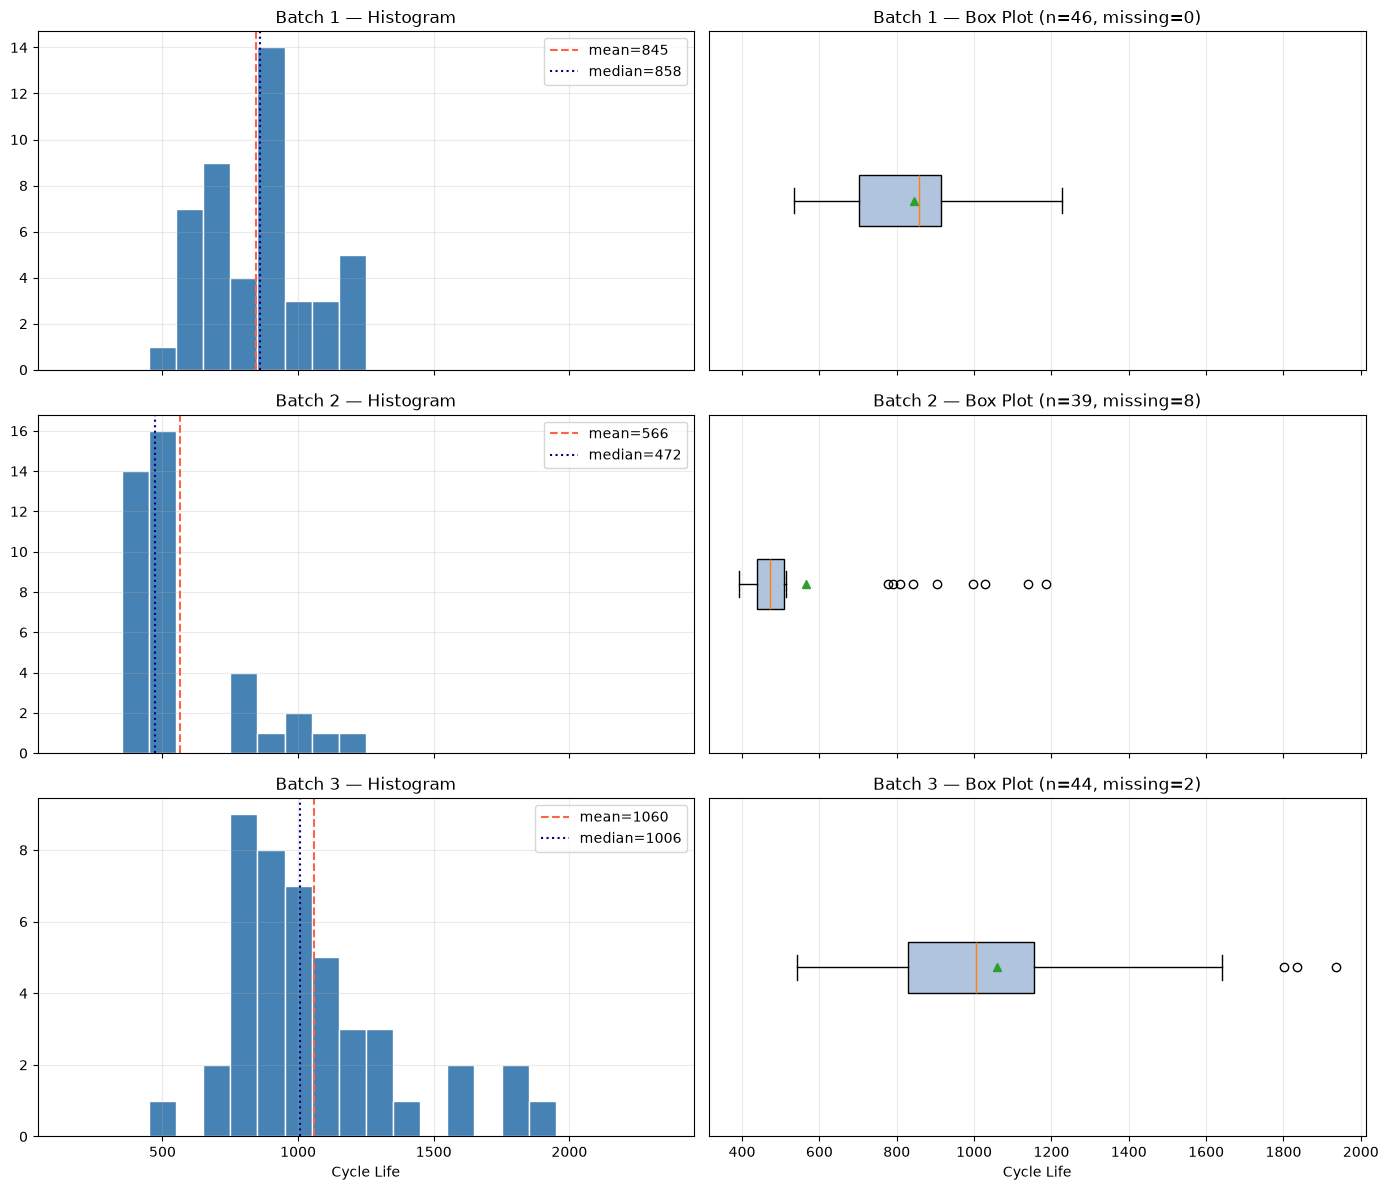

In [8]:
# 수명 값이 유효한 셀만 분포·그룹 분석에 사용한다.
life_data = cells_df.replace({'cycle_life': [np.inf, -np.inf]}, np.nan).dropna(subset=['cycle_life']).copy()
life_counts = cells_df.groupby('batch')['cycle_life'].agg(total='size', valid='count')
life_counts['missing'] = life_counts['total'] - life_counts['valid']
display(life_counts)

cycle_stats = life_data.groupby('batch')['cycle_life'].agg(
    count='count', mean='mean', median='median', std='std', min='min', max='max',
    q1=lambda x: x.quantile(.25), q3=lambda x: x.quantile(.75), skew=lambda x: x.skew(),
)
cycle_stats['IQR'] = cycle_stats['q3'] - cycle_stats['q1']
display(cycle_stats)

life_data['life_group'] = np.select(
    [life_data['cycle_life'] < 500, life_data['cycle_life'] > 1000],
    ['Short (<500)', 'Long (>1000)'], default='Middle (500–1000)',
)
life_group_ratio = pd.crosstab(life_data['batch'], life_data['life_group'], normalize='index') * 100
life_group_ratio = life_group_ratio.reindex(columns=['Short (<500)', 'Middle (500–1000)', 'Long (>1000)'], fill_value=0)
display(life_group_ratio.round(1).rename_axis(columns='life_group_percent'))

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex='col')
for row, batch_name in enumerate(BATCH_FILES):
    values = life_data.loc[life_data['batch'] == batch_name, 'cycle_life'].to_numpy()
    if len(values) == 0:
        axes[row, 0].set_title(f'{batch_name} — No valid Cycle Life')
        axes[row, 1].set_title(f'{batch_name} — No valid Cycle Life')
        continue
    axes[row, 0].hist(values, bins=np.arange(150, 2401, 100), color='steelblue', edgecolor='white')
    axes[row, 0].axvline(values.mean(), color='tomato', linestyle='--', label=f'mean={values.mean():.0f}')
    axes[row, 0].axvline(np.median(values), color='navy', linestyle=':', label=f'median={np.median(values):.0f}')
    axes[row, 0].set_title(f'{batch_name} — Histogram')
    axes[row, 0].legend()
    axes[row, 1].boxplot(values, orientation='horizontal', patch_artist=True, showmeans=True, boxprops={'facecolor': 'lightsteelblue'})
    axes[row, 1].set_title(f'{batch_name} — Box Plot (n={len(values)}, missing={life_counts.loc[batch_name, "missing"]})')
    axes[row, 1].set_yticks([])
axes[-1, 0].set_xlabel('Cycle Life')
axes[-1, 1].set_xlabel('Cycle Life')
plt.tight_layout()
plt.show()


### Question 1 답변 — Cycle Life 분포

**관찰**

Histogram은 과제에서 지정한 150~2,300 Cycle 범위를 포함해 표시했으며, 실제 수명 라벨의 범위는 392~1,935 Cycle이다. 수명 라벨이 있는 129개 셀만 수명 분포·비율 계산에 사용했다. Batch 2의 8개, Batch 3의 2개는 수명을 알 수 없어 분모에서 제외했다.

| 배치 | 유효 셀 수 | 평균 / 중앙값 (Cycle) | 최솟값~최댓값 (Cycle) | 단수명 <500 | 장수명 >1,000 |
|---|---:|---:|---:|---:|---:|
| Batch 1 | 46 | 844.7 / 858.5 | 534~1,227 | 0/46 = 0.0% | 10/46 = 21.7% |
| Batch 2 | 39 | 565.7 / 472.0 | 392~1,186 | 28/39 = 71.8% | 3/39 = 7.7% |
| Batch 3 | 44 | 1,059.7 / 1,005.5 | 541~1,935 | 0/44 = 0.0% | 23/44 = 52.3% |

배치별 왜도는 0.453 / 1.637 / 1.255이다. Batch 2는 짧은 수명에 관측값이 집중되고 일부 장수명 셀이 오른쪽 꼬리를 만들며, Batch 3는 장수명 비중과 수명 변동이 가장 크다. 표준편차는 각각 184.6 / 222.2 / 313.9 Cycle이다.

**해석 — 짧은 셀과 통계적 이상치는 구분해야 한다**

배치별 `Q1−1.5×IQR` 미만을 하단 이상치, `Q3+1.5×IQR` 초과를 상단 이상치로 확인하면, 세 배치 모두 하단 이상치는 없다. Batch 1은 이상치가 없고, Batch 2는 상단 경계 612 Cycle을 넘는 9개 셀(`Batch2_cell_007`, `_008`, `_009`, `_032`, `_033`, `_034`, `_043`, `_044`, `_045`)이 상단 이상치다. Batch 3는 상단 경계 1,646.125 Cycle을 넘는 `Batch3_cell_007`(1,836), `Batch3_cell_038`(1,935), `Batch3_cell_045`(1,801)가 상단 이상치다. 이는 수명 분포에서 드문 값이라는 뜻이지 측정 오류라는 뜻은 아니다.

배치별 가장 짧은 셀은 다음과 같다.

- Batch 1: `Batch1_cell_020`, 534 Cycle, `5.4C(80%)-5.4C`. 같은 정책의 `_021`도 559 Cycle로 짧다.
- Batch 2: `Batch2_cell_019`, 392 Cycle, `6C(60%)-3C`. `_006`(393), `_015`(396)는 `3.6C(9%)-5C` 정책을 사용한다.
- Batch 3: `Batch3_cell_028`, 541 Cycle, `3.7C(31%)-5.9C-newstructure`. 같은 정책의 평균은 660 Cycle(n=3)로 Batch 3의 정책 중 가장 낮다.

이 셀들은 특정 충전 정책과 함께 짧은 수명을 보이지만, 초기 C-rate 하나만으로 원인을 설명할 수는 없다. 구조·실험 조건의 영향도 분리되지 않았으므로 물리적 고장 원인은 현재 EDA만으로 확정할 수 없다.

**질문에 대한 답변**

Cycle Life는 배치마다 분포가 다르다. Batch 2는 단수명 중심, Batch 3는 장수명 중심이며 Batch 1은 그 사이에 위치한다. 유독 짧은 셀과 충전 정책은 식별했지만, 이들은 배치 내부의 하단 IQR 이상치는 아니며 짧아진 인과적 원인은 추가 확인이 필요하다.


# Question 2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

첫 사이클에는 0이나 비정상값이 있을 수 있으므로 Cycle 2~5의 QD 중앙값을 초기 용량으로 사용하고, `QD / 초기 QD`로 용량 유지율을 계산한다.

수명 미확인 셀의 곡선은 회색으로 표시한다. 그래프 아래에서 Cycle 100·200·300·500·800·1000의 배치별 QD와 용량 유지율을 수치로 비교하고, 셀별 유지율 및 마지막 관측값도 확인한다. 유지율 1.0은 100%를 뜻한다. 후반 Cycle의 표본 수가 줄어들므로 각 시점의 평균은 같은 셀 집단의 평균이 아니다. 측정 이상치가 평균에 영향을 줄 수 있어 중앙값과 사분위수도 함께 확인한다.

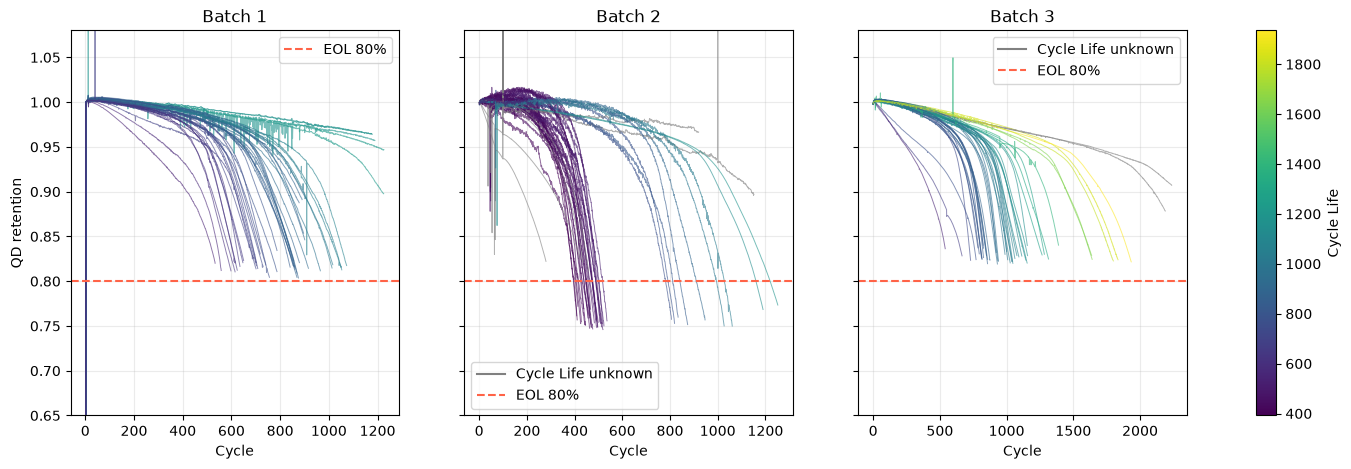

배치별 주요 Cycle의 방전 용량 및 용량 유지율


,batch,cycle,n_cells,QD_mean,QD_median,retention_mean,retention_median,retention_q1,retention_q3
0,Batch 1,100.0000,46,1.0807,1.0815,1.0010,1.0012,1.0002,1.0028
1,Batch 1,200.0000,46,1.0757,1.0779,0.9964,0.9975,0.9958,0.9995
2,Batch 1,300.0000,46,1.0691,1.0718,0.9902,0.9921,0.9892,0.9955
3,Batch 1,500.0000,46,1.0452,1.0567,0.9681,0.9777,0.9656,0.9837
4,Batch 1,800.0000,26,0.9942,1.0057,0.9195,0.9256,0.8717,0.9510
5,Batch 1,"1,000.0000",10,0.9809,0.9939,0.9091,0.9208,0.8544,0.9681
6,Batch 2,100.0000,47,1.1817,1.0975,1.0829,1.0011,0.9972,1.0066
7,Batch 2,200.0000,45,1.0855,1.0912,0.9936,0.9970,0.9902,1.0034
8,Batch 2,300.0000,44,1.0641,1.0640,0.9737,0.9750,0.9572,0.9943
9,Batch 2,500.0000,18,0.9946,1.0552,0.9093,0.9726,0.8008,0.9839


셀별 초기 용량·주요 Cycle 유지율·마지막 관측값 (미도달 Cycle은 NaN)


,batch,cell_id,cycle_life,initial_QD,retention_cycle_100,retention_cycle_200,retention_cycle_300,retention_cycle_500,retention_cycle_800,retention_cycle_1000,last_observed_cycle,last_QD,last_retention
0,Batch 1,Batch1_cell_000,"1,190.0000",1.0722,1.0035,0.9972,0.9976,0.9899,0.9770,0.9689,"1,189.0000",1.0262,0.9571
1,Batch 1,Batch1_cell_001,"1,179.0000",1.0770,1.0034,1.0014,0.9983,0.9924,0.9813,0.9726,"1,178.0000",1.0382,0.9640
2,Batch 1,Batch1_cell_002,"1,177.0000",1.0818,1.0029,1.0010,0.9981,0.9923,0.9816,0.9716,"1,176.0000",1.0433,0.9644
3,Batch 1,Batch1_cell_003,"1,226.0000",1.0816,1.0029,0.9999,0.9969,0.9883,0.9754,0.9566,"1,225.0000",0.9709,0.8977
4,Batch 1,Batch1_cell_004,"1,227.0000",1.0794,1.0030,1.0004,0.9976,0.9895,0.9778,0.9656,"1,226.0000",1.0220,0.9468
5,Batch 1,Batch1_cell_005,"1,074.0000",1.0771,1.0025,0.9989,0.9950,0.9871,0.9563,0.8849,"1,073.0000",0.8805,0.8175
6,Batch 1,Batch1_cell_006,636.0000,1.0778,1.0013,0.9937,0.9840,0.9505,NaN,NaN,635.0000,0.8801,0.8165
7,Batch 1,Batch1_cell_007,870.0000,1.0955,1.0002,0.9958,0.9905,0.9772,0.8652,NaN,869.0000,0.8811,0.8043
8,Batch 1,Batch1_cell_008,879.0000,1.0917,1.0022,0.9989,0.9942,0.9828,0.9262,NaN,878.0000,0.9690,0.8876
9,Batch 1,Batch1_cell_009,"1,054.0000",1.0840,1.0034,1.0005,0.9963,0.9860,0.9517,0.8590,"1,053.0000",0.8809,0.8127


In [9]:
initial_qd = (
    summary_df.loc[summary_df['cycle'].between(2, 5)]
    .groupby(['batch', 'cell_id'])['QD'].median().rename('initial_QD')
)
# 셀을 다시 실행해도 기존 initial_QD 열과 충돌하지 않도록 갱신한다.
summary_df = summary_df.drop(columns=['initial_QD'], errors='ignore').join(initial_qd, on=['batch', 'cell_id'])
summary_df['qd_retention'] = summary_df['QD'] / summary_df['initial_QD']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
norm = plt.Normalize(cells_df['cycle_life'].min(), cells_df['cycle_life'].max())
for ax, batch_name in zip(axes, BATCH_FILES):
    batch_data = summary_df.loc[summary_df['batch'] == batch_name]
    for _, cell_data in batch_data.groupby('cell_id'):
        life = cell_data['cycle_life'].iloc[0]
        color = plt.cm.viridis(norm(life)) if np.isfinite(life) else 'gray'
        ax.plot(cell_data['cycle'], cell_data['qd_retention'], color=color, alpha=.6, linewidth=.7)
    if batch_data['cycle_life'].isna().any():
        ax.plot([], [], color='gray', label='Cycle Life unknown')
    ax.axhline(.8, color='tomato', linestyle='--', label='EOL 80%')
    ax.set_title(batch_name)
    ax.set_xlabel('Cycle')
    ax.set_ylim(.65, 1.08)
    ax.legend()
axes[0].set_ylabel('QD retention')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axes, label='Cycle Life')
plt.show()

# 그래프에 사용한 실제 측정값의 주요 Cycle 수치 요약
CHECKPOINT_CYCLES = [100, 200, 300, 500, 800, 1000]
checkpoint_data = summary_df.loc[summary_df['cycle'].isin(CHECKPOINT_CYCLES)].copy()
retention_summary = checkpoint_data.groupby(['batch', 'cycle']).agg(
    n_cells=('cell_id', 'nunique'),
    QD_mean=('QD', 'mean'), QD_median=('QD', 'median'),
    retention_mean=('qd_retention', 'mean'), retention_median=('qd_retention', 'median'),
    retention_q1=('qd_retention', lambda x: x.quantile(.25)),
    retention_q3=('qd_retention', lambda x: x.quantile(.75)),
).reset_index()
print('배치별 주요 Cycle의 방전 용량 및 용량 유지율')
display(retention_summary.round(4))

retention_by_cell = checkpoint_data.pivot_table(
    index=['batch', 'cell_id'], columns='cycle', values='qd_retention', aggfunc='first',
).reindex(columns=CHECKPOINT_CYCLES)
retention_by_cell.columns = [f'retention_cycle_{cycle}' for cycle in CHECKPOINT_CYCLES]
last_observation = (
    summary_df.sort_values('cycle').groupby(['batch', 'cell_id']).tail(1)
    [['batch', 'cell_id', 'cycle', 'QD', 'qd_retention']]
    .rename(columns={'cycle': 'last_observed_cycle', 'QD': 'last_QD', 'qd_retention': 'last_retention'})
)
degradation_numeric = (
    cells_df[['batch', 'cell_id', 'cycle_life']]
    .merge(initial_qd.reset_index(), on=['batch', 'cell_id'], how='left')
    .merge(retention_by_cell.reset_index(), on=['batch', 'cell_id'], how='left')
    .merge(last_observation, on=['batch', 'cell_id'], how='left')
    .sort_values(['batch', 'cell_id'])
)
print('셀별 초기 용량·주요 Cycle 유지율·마지막 관측값 (미도달 Cycle은 NaN)')
with pd.option_context('display.max_rows', None):
    display(degradation_numeric.round(4))


knee_cycle                   knee_ratio              
            median     mean      std     median   mean    std
batch                                                        
Batch 1   585.5000 584.5652 133.2744     0.7310 0.7004 0.0956
Batch 2   345.0000 412.0851 198.1949     0.7553 0.7506 0.0447
Batch 3   779.0000 848.3261 303.0503     0.7598 0.7615 0.0319

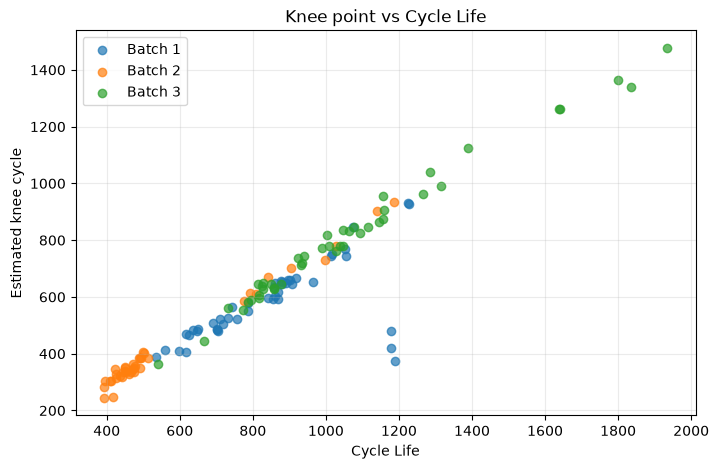

In [10]:
def estimate_knee(group):
    data = group[['cycle', 'qd_retention']].replace([np.inf, -np.inf], np.nan).dropna().sort_values('cycle')
    data = data.loc[data['cycle'] >= 50]
    if len(data) < 50:
        return np.nan
    x = data['cycle'].to_numpy(float)
    y = data['qd_retention'].rolling(21, center=True, min_periods=5).median().interpolate().to_numpy(float)
    x_scaled = (x - x.min()) / max(x.max() - x.min(), 1)
    straight_line = y[0] + (y[-1] - y[0]) * x_scaled
    return x[np.nanargmax(y - straight_line)]

knee_rows = []
for (batch_name, cell_id), group in summary_df.groupby(['batch', 'cell_id']):
    knee_rows.append({
        'batch': batch_name, 'cell_id': cell_id,
        'cycle_life': group['cycle_life'].iloc[0],
        'knee_cycle': estimate_knee(group),
    })
knee_df = pd.DataFrame(knee_rows)
knee_df['knee_ratio'] = knee_df['knee_cycle'] / knee_df['cycle_life']
display(knee_df.groupby('batch')[['knee_cycle', 'knee_ratio']].agg(['median', 'mean', 'std']))

fig, ax = plt.subplots(figsize=(8, 5))
for batch_name, group in knee_df.groupby('batch'):
    ax.scatter(group['cycle_life'], group['knee_cycle'], alpha=.7, label=batch_name)
ax.set(xlabel='Cycle Life', ylabel='Estimated knee cycle', title='Knee point vs Cycle Life')
ax.legend()
plt.show()


### Question 2 답변 — 방전 용량 감소와 Knee point

**관찰 — 초기에는 완만하고 이후 감소가 가팔라진다**

셀별 열화 곡선은 초기 유지율이 약 100% 부근에 있다가, 뒤쪽에서 감소 기울기가 커지는 비선형 형태를 보인다. Batch 2의 단수명 셀은 약 300~500 Cycle 구간에서 급격한 감소가 두드러지고, Batch 3의 장수명 셀은 그 시점이 더 뒤에 나타난다. 모든 셀이 같은 속도로 열화하거나 동일한 시점에 꺾이는 것은 아니다.

앞의 수치 출력과 같은 기준으로, 수명 미확인 셀까지 포함한 측정값의 용량 유지율 중앙값은 다음과 같다. 초기 용량은 Cycle 2~5의 QD 중앙값이다.

| 관측 Cycle | Batch 1 유지율 (관측 셀 수) | Batch 2 유지율 (관측 셀 수) | Batch 3 유지율 (관측 셀 수) |
|---|---:|---:|---:|
| 100 | 100.12% (46) | 100.11% (47) | 100.04% (46) |
| 300 | 99.21% (46) | 97.50% (44) | 99.29% (46) |
| 500 | 97.77% (46) | 97.26% (18) | 98.33% (46) |
| 1,000 | 92.08% (10) | 90.71% (5) | 91.83% (25) |

**해석 — 표본 변화와 측정 스파이크에 주의해야 한다**

후반 Cycle에는 그 시점까지 기록된 셀만 남는다. 특히 Batch 2는 Cycle 300의 44개에서 Cycle 500의 18개로 줄어들므로, 위 중앙값을 같은 셀 집단의 연속 곡선으로 해석해서는 안 된다. Batch 2의 Cycle 100 평균 유지율 108.29%와 Cycle 1,000 평균 106.34%는 중앙값 100.11% / 90.71%와 크게 다르며, 일부 비정상적으로 큰 값의 영향을 받는다. 평균 증가를 실제 용량 회복으로 단정할 수 없다.

**관찰·해석 — Knee point 탐색 결과**

현재 방법은 Cycle 50 이후 유지율을 21개 관측값의 이동 중앙값으로 평활화하고, 시작점과 끝점을 잇는 직선에서 곡선이 가장 위로 벗어나는 Cycle을 knee 후보로 잡는다. 전체 측정 셀의 knee 중앙값은 Batch 1=585.5, Batch 2=345.0, Batch 3=779.0 Cycle이다.

수명 라벨이 있는 셀을 그룹별로 보조 집계하면 다음과 같다.

- Batch 1: 장수명 747.5 Cycle(n=10), 중간 수명 557.0 Cycle(n=36).
- Batch 2: 장수명 904.0 Cycle(n=3), 중간 수명 612.5 Cycle(n=8), 단수명 337.0 Cycle(n=28).
- Batch 3: 장수명 873.0 Cycle(n=23), 중간 수명 633.0 Cycle(n=21).

같은 배치 안에서도 장수명 셀의 knee 후보가 더 늦다. 다만 이는 곡선 모양으로 탐색한 추정값이며, 측정 이상과 관측 종료점의 영향을 받는다. 검증된 물리적 열화 시작점이나 정확한 수명 종료점으로 간주하지 않는다. 초기 용량 대비 80% 선 역시 그래프의 비교 기준이며, 제공된 `cycle_life`를 이 선의 교차점으로 재정의하지 않는다.

**질문에 대한 답변**

방전 용량은 일정한 속도로만 감소하지 않는다. 초기 완만한 열화 후 감소가 가속되는 형태가 관찰되며, knee 후보는 Batch 2에서 가장 이르고 Batch 3에서 가장 늦다. 전체 수명 구간으로 구한 knee는 설명용이며 Cycle 100 시점의 예측 입력으로 사용하지 않는다.


# Question 3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

원본 로딩 단계에서 읽은 Qdlin으로 `ΔQ(V) = Qdlin(Cycle 100) − Qdlin(Cycle 10)`을 계산한다. 이 질문은 곡선의 차이를 시각화하고, 수명과의 관계를 분석할 수 있는 **탐색용 통계 피처**까지 생성한다. 아직 모델 입력 변수를 선정하는 단계는 아니다.


### 3.1 ΔQ(V) 계산 및 전압축 정렬

Cycle 100과 Cycle 10의 방전 용량 차이를 계산한다. 셀별 전압축을 공통 2.0~3.6V의 1,000개 지점에 보간해 같은 전압에서 곡선을 비교한다. 원본 전압 범위 밖은 NaN으로 두고, 유효한 지점이 10개 미만이면 ΔQ 분석에서만 제외한다. 원본 셀·사이클 데이터는 삭제하지 않는다.


In [11]:
COMMON_VOLTAGE = np.linspace(2.0, 3.6, 1000)

def align_curve(voltage, values):
    voltage = np.asarray(voltage, dtype=float).reshape(-1)
    values = np.asarray(values, dtype=float).reshape(-1)
    n = min(len(voltage), len(values))
    voltage, values = voltage[:n], values[:n]
    valid = np.isfinite(voltage) & np.isfinite(values)
    voltage, values = voltage[valid], values[valid]
    if len(values) < 10:
        return np.full_like(COMMON_VOLTAGE, np.nan)
    order = np.argsort(voltage)
    voltage, values = voltage[order], values[order]
    voltage, unique_index = np.unique(voltage, return_index=True)
    values = values[unique_index]
    return np.interp(COMMON_VOLTAGE, voltage, values, left=np.nan, right=np.nan)

delta_curves = []
for item in raw_qv_data:
    delta_q = align_curve(item['voltage'], item['qdlin_100'] - item['qdlin_10'])
    if np.isfinite(delta_q).sum() < 10:
        continue
    delta_curves.append({
        'batch': item['batch'], 'cell_id': item['cell_id'],
        'cycle_life': item['cycle_life'], 'delta_q': delta_q,
    })
print('분석 가능한 ΔQ(V) 곡선 수:', len(delta_curves))


분석 가능한 ΔQ(V) 곡선 수: 139


### 3.2 EDA용 통계 피처 생성

곡선을 셀당 숫자로 요약해 수명과의 관계를 탐색한다. 평균·표본 표준편차·최솟값·범위·표본분산의 log10·절대 면적을 계산한다. 이는 Feature Engineering 중 **피처 추출**에 해당하지만, 여섯 개를 모두 모델에 넣는다는 뜻은 아니다. 실제 입력 후보는 EDA를 마친 뒤 11절에서 선정한다.

각 셀의 초기 측정값에 고정된 계산식을 적용하며, 타깃이나 다른 셀의 통계량으로 피처를 만들지 않는다. 기존 계산식과 피처 이름은 유지해 DAY2와 연결한다.


In [12]:
def summarize_delta_curve(item):
    delta_q = item['delta_q']
    valid = np.isfinite(delta_q)
    values = delta_q[valid]
    variance = np.var(values, ddof=1)
    return {
        'batch': item['batch'], 'cell_id': item['cell_id'],
        'cycle_life': item['cycle_life'],
        'delta_q_mean': values.mean(),
        'delta_q_std': values.std(ddof=1),
        'delta_q_min': values.min(),
        'delta_q_range': np.ptp(values),
        'log10_delta_q_var': np.log10(max(variance, np.finfo(float).tiny)),
        'delta_q_abs_area': np.trapezoid(np.abs(values), COMMON_VOLTAGE[valid]),
    }

delta_df = pd.DataFrame([summarize_delta_curve(item) for item in delta_curves])
print('delta_df:', delta_df.shape)
display(delta_df.head())


delta_df: (139, 9)


,batch,cell_id,cycle_life,delta_q_mean,delta_q_std,delta_q_min,delta_q_range,log10_delta_q_var,delta_q_abs_area
0,Batch 1,Batch1_cell_000,"1,190.0000",-0.0029,0.0031,-0.0084,0.0092,-5.0144,0.0044
1,Batch 1,Batch1_cell_001,"1,179.0000",-0.0041,0.0031,-0.0110,0.0109,-5.0137,0.0062
2,Batch 1,Batch1_cell_002,"1,177.0000",-0.0045,0.0043,-0.0172,0.0172,-4.7366,0.0067
3,Batch 1,Batch1_cell_003,"1,226.0000",-0.0075,0.0060,-0.0190,0.0191,-4.4423,0.0112
4,Batch 1,Batch1_cell_004,"1,227.0000",-0.0058,0.0047,-0.0140,0.0140,-4.6474,0.0086


### 3.3 곡선 시각화 및 통계 피처와 수명의 관계

생성한 곡선과 탐색용 통계 피처를 사용해 장·단수명 그룹 및 배치 간 특징을 비교한다.


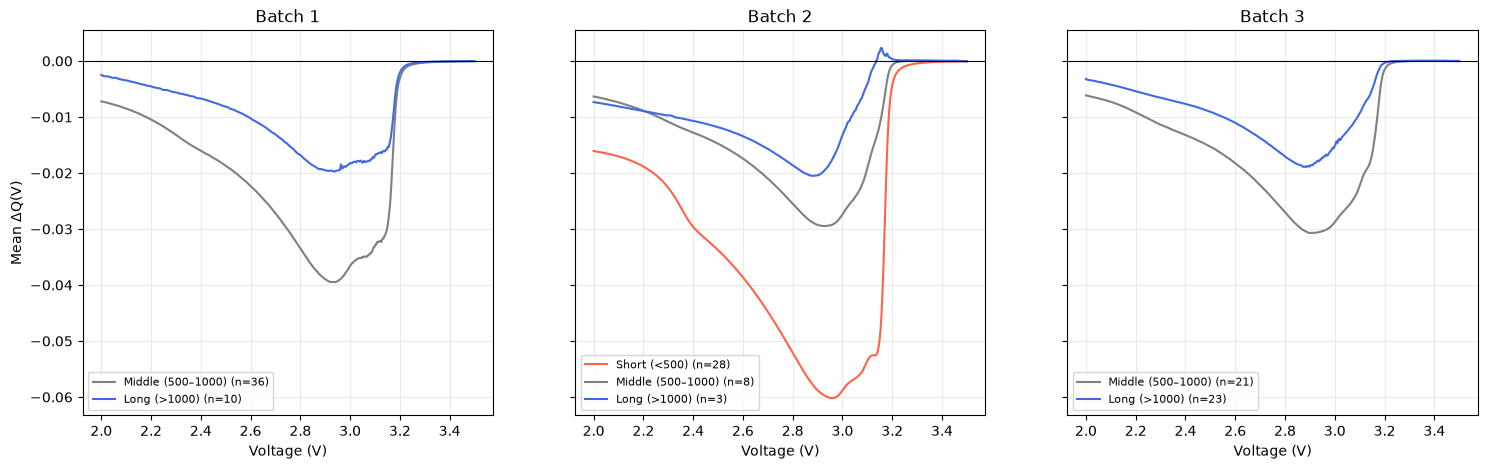

,Batch 1,Batch 2,Batch 3
delta_q_mean,0.8281,0.6972,0.7561
delta_q_std,-0.8712,-0.7104,-0.7999
delta_q_min,0.8526,0.6609,0.7760
delta_q_range,-0.8526,-0.6499,-0.6769
log10_delta_q_var,-0.8712,-0.7104,-0.7999
delta_q_abs_area,-0.8281,-0.6970,-0.7577


In [13]:
def life_group(value):
    if not np.isfinite(value):
        return None
    if value < 500:
        return 'Short (<500)'
    if value > 1000:
        return 'Long (>1000)'
    return 'Middle (500–1000)'

colors = {'Short (<500)': 'tomato', 'Middle (500–1000)': 'gray', 'Long (>1000)': 'royalblue'}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, batch_name in zip(axes, BATCH_FILES):
    curves = [item for item in delta_curves if item['batch'] == batch_name]
    for group_name, color in colors.items():
        selected = [item['delta_q'] for item in curves if life_group(item['cycle_life']) == group_name]
        if selected:
            ax.plot(COMMON_VOLTAGE, np.nanmean(np.vstack(selected), axis=0), color=color, label=f'{group_name} (n={len(selected)})')
    ax.axhline(0, color='black', linewidth=.8)
    ax.set_title(batch_name)
    ax.set_xlabel('Voltage (V)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Mean ΔQ(V)')
plt.show()

delta_columns = ['delta_q_mean', 'delta_q_std', 'delta_q_min', 'delta_q_range', 'log10_delta_q_var', 'delta_q_abs_area']
delta_correlations = pd.DataFrame({
    batch: group[delta_columns + ['cycle_life']].corr(method='spearman')['cycle_life'].drop('cycle_life')
    for batch, group in delta_df.groupby('batch')
})
display(delta_correlations)


### Question 3 답변 — 초기 ΔQ(V) 곡선의 차이와 통계 피처

**관찰 — 수명이 짧은 그룹의 곡선이 더 아래로 내려간다**

`ΔQ(V)=Q(Cycle 100)−Q(Cycle 10)`이므로 음수는 같은 전압에서 Cycle 100의 방전 용량이 더 작다는 뜻이다. 평균 곡선의 그룹 차이는 주로 약 2.4~3.2V, 특히 2.8~3.1V에서 크게 나타나고 3.2V 이후에는 대부분 0 부근으로 모인다.

단수명과 장수명 그룹이 모두 있는 Batch 2에서, 2.8~3.2V 구간의 셀별 ΔQ 평균을 그룹 평균으로 비교하면 단수명은 약 −0.0525, 장수명은 −0.0116이다(원본 Qdlin 단위). 단수명 곡선의 음의 변화가 더 크다. 그룹별 통계 피처 중앙값도 이를 뒷받침한다.

| Batch 2 그룹 | 셀 수 | ΔQ 표준편차 중앙값 | log10(ΔQ 분산) 중앙값 | ΔQ 절대 면적 중앙값 |
|---|---:|---:|---:|---:|
| 단수명 <500 | 28 | 0.0189 | −3.4459 | 0.0430 |
| 장수명 >1,000 | 3 | 0.0073 | −4.2714 | 0.0132 |

Batch 1·3에는 500 Cycle 미만 셀이 없어 장수명 대 단수명을 직접 비교할 수 없다. 대신 장수명과 중간 수명 그룹을 비교했으며, 두 배치에서도 장수명 그룹의 ΔQ가 0에 더 가깝고 변동성이 작다.

**해석 — 가장 강한 단조 관계는 ΔQ 변동성이다**

ΔQ 표준편차와 로그 분산의 수명 대비 Spearman 상관은 두 피처 모두 Batch 1=−0.871, Batch 2=−0.710, Batch 3=−0.800으로, 계산한 여섯 ΔQ 통계 중 각 배치에서 절대 상관이 가장 크다. 분산·표준편차가 큰 셀일수록 수명이 짧은 경향이 세 배치에서 일관된다. 절대 면적도 −0.828 / −0.697 / −0.758의 음의 관계를 보이지만 변동성 피처보다 약하다.

로그 분산이 더 음수라는 것은 분산이 더 작다는 뜻이다. 평균·최솟값·범위·절대 면적도 초기 곡선의 크기와 형태를 요약하지만 서로 상당한 정보를 공유한다. Batch 2 장수명 그룹은 n=3이므로 평균 곡선만으로 개별 셀의 수명 그룹을 완벽하게 구분한다고 주장할 수 없다.

**질문에 대한 답변**

초기 Cycle 10과 100 사이의 ΔQ(V)만으로도 수명 그룹의 차이가 관찰된다. 단수명 셀은 더 큰 음의 변화와 변동성을 보이며, 이를 숫자로 표현한 표준편차·로그 분산이 수명과 가장 강한 단조 관계를 보인다. 이는 탐색 결과이지 분류 정확도나 예측 성능을 검증한 결과는 아니다.


# Question 4. 충전 조건(C-rate)과 수명의 관계는?

정책 문자열에서 1단계 C-rate, 전환 SOC, 2단계 C-rate를 추출하고 표본 수와 표준편차를 함께 본다.

,batch,charging_policy,mean,std,count
3,Batch 1,4C(80%)-4C,"1,226.5000",0.7071,2
0,Batch 1,3.6C(80%)-3.6C,"1,182.0000",7.0000,3
1,Batch 1,4.4C(80%)-4.4C,"1,074.0000",NaN,1
20,Batch 1,8C(15%)-3.6C,"1,008.5000",60.1041,2
4,Batch 1,5.4C(40%)-3.6C,966.5000,123.7437,2
11,Batch 1,6C(30%)-3.6C,952.5000,86.9741,2
13,Batch 1,6C(40%)-3C,935.5000,115.2584,2
5,Batch 1,5.4C(50%)-3.6C,899.5000,3.5355,2
15,Batch 1,6C(50%)-3C,888.5000,40.3051,2
7,Batch 1,5.4C(60%)-3.6C,859.5000,3.5355,2


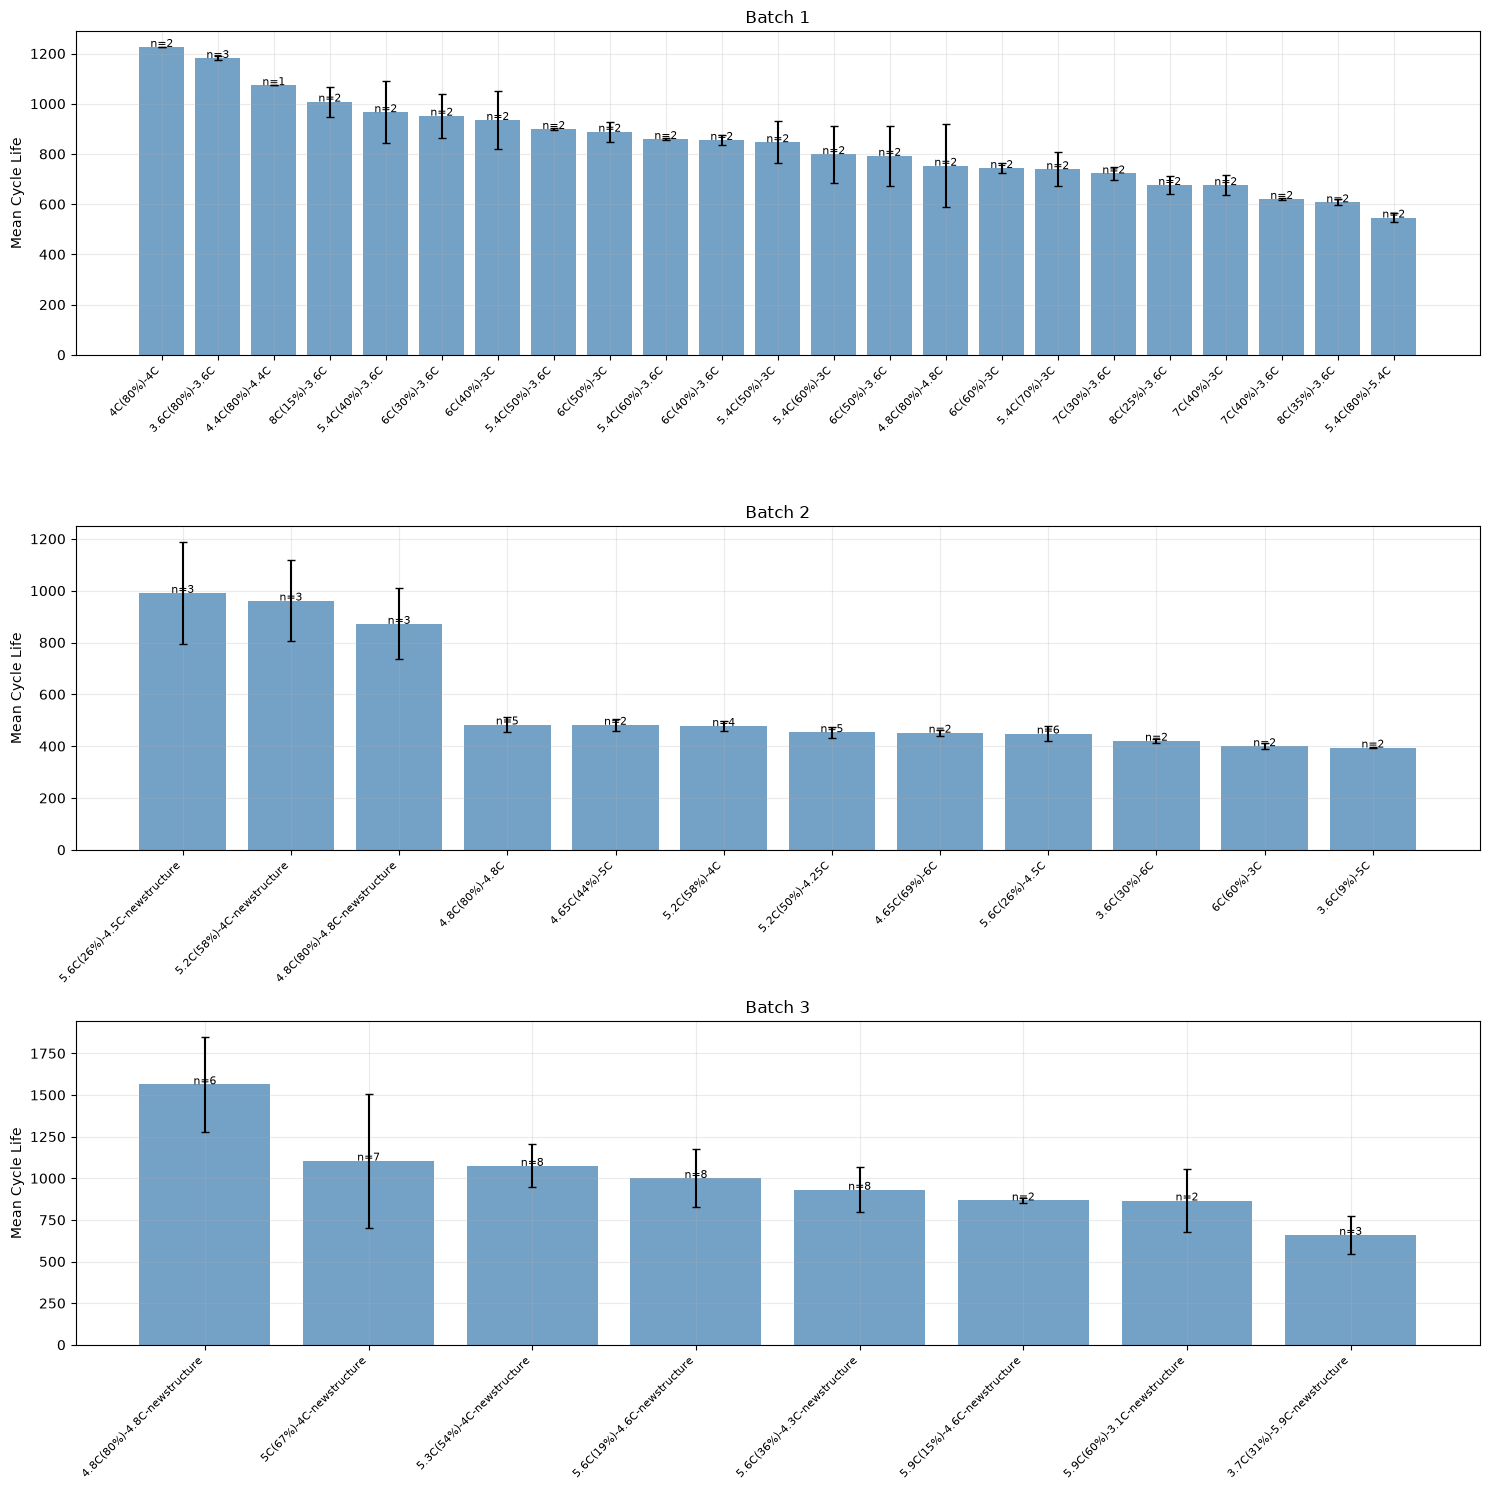

,batch,feature,n,spearman_rho,p_value
0,Batch 1,c_rate_1,46,-0.4827,0.0007
1,Batch 1,switch_soc,46,0.1852,0.2180
2,Batch 1,c_rate_2,46,0.0474,0.7544
3,Batch 2,c_rate_1,39,0.0551,0.7390
4,Batch 2,switch_soc,39,0.2878,0.0756
5,Batch 2,c_rate_2,39,-0.1188,0.4712
6,Batch 3,c_rate_1,44,-0.2289,0.1351
7,Batch 3,switch_soc,44,0.4433,0.0026
8,Batch 3,c_rate_2,44,0.0157,0.9192


In [22]:
POLICY_PATTERN = re.compile(r'(\d+(?:\.\d+)?)C\((\d+(?:\.\d+)?)%\)-(\d+(?:\.\d+)?)C')

def parse_policy(value):
    match = POLICY_PATTERN.search(str(value).replace(' ', ''))
    return tuple(map(float, match.groups())) if match else (np.nan, np.nan, np.nan)

cells_df[['c_rate_1', 'switch_soc', 'c_rate_2']] = pd.DataFrame(
    cells_df['charging_policy'].map(parse_policy).tolist(), index=cells_df.index,
)
policy_summary = cells_df.dropna(subset=['cycle_life']).groupby(['batch', 'charging_policy'])['cycle_life'].agg(['mean', 'std', 'count']).reset_index()
display(policy_summary.sort_values(['batch', 'mean'], ascending=[True, False]))

fig, axes = plt.subplots(3, 1, figsize=(15, 15))
for ax, batch_name in zip(axes, BATCH_FILES):
    plot_data = policy_summary.loc[policy_summary['batch'] == batch_name].sort_values('mean', ascending=False)
    x = np.arange(len(plot_data))
    ax.bar(x, plot_data['mean'], yerr=plot_data['std'].fillna(0), color='steelblue', alpha=.75, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data['charging_policy'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean Cycle Life')
    ax.set_title(batch_name)
    for position, count in enumerate(plot_data['count']):
        ax.text(position, plot_data.iloc[position]['mean'], f'n={count}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

c_rate_rows = []
for batch_name, group in cells_df.groupby('batch'):
    for feature in ['c_rate_1', 'switch_soc', 'c_rate_2']:
        valid = group[[feature, 'cycle_life']].dropna()
        rho, p_value = stats.spearmanr(valid[feature], valid['cycle_life']) if len(valid) >= 3 else (np.nan, np.nan)
        c_rate_rows.append({'batch': batch_name, 'feature': feature, 'n': len(valid), 'spearman_rho': rho, 'p_value': p_value})
display(pd.DataFrame(c_rate_rows))


### Question 4 답변 — 충전 조건과 수명의 관계

**관찰 — 프로토콜에 따라 평균 수명이 다르다**

- Batch 1: `4C(80%)-4C`는 평균 1,226.5 Cycle(n=2), `5.4C(80%)-5.4C`는 546.5 Cycle(n=2)이다. 반면 `8C(15%)-3.6C`는 1,008.5 Cycle(n=2)로, 첫 단계 C-rate가 높다고 항상 짧은 수명은 아니다.
- Batch 2: `5.6C(26%)-4.5C-newstructure`는 평균 991.3 Cycle(n=3)이지만, 같은 C-rate·전환 SOC의 `5.6C(26%)-4.5C`는 448.5 Cycle(n=6)이다. `3.6C(9%)-5C`는 394.5 Cycle(n=2)로 가장 짧다.
- Batch 3: `4.8C(80%)-4.8C-newstructure`는 평균 1,564.2 Cycle(n=6), `3.7C(31%)-5.9C-newstructure`는 660.0 Cycle(n=3)이다.

| 충전 조건과 수명의 Spearman ρ | Batch 1 | Batch 2 | Batch 3 |
|---|---:|---:|---:|
| 첫 단계 C-rate | −0.483 | +0.055 | −0.229 |
| 전환 SOC | +0.185 | +0.288 | +0.443 |
| 두 번째 단계 C-rate | +0.047 | −0.119 | +0.016 |

**해석 — 첫 단계 C-rate 하나로 수명을 설명할 수 없다**

Batch 1에서는 첫 단계 C-rate가 클수록 수명이 짧은 관계가 보이지만, Batch 2에서는 관계가 거의 없다. 두 번째 단계 C-rate와 수명의 단일 상관도 세 배치 모두 약하다. 전환 SOC는 양의 관계를 보이며 Batch 3에서 상대적으로 크다. 같은 수치형 프로토콜이라도 `newstructure` 유무에 따라 수명이 다른 사례가 있어, 구조·실험 조건을 통제하지 않은 비교로 충전 속도의 인과적 효과를 판단할 수 없다. 정책별 표본은 대체로 1~8개이고 정책 내 변동도 있으므로 평균 순위를 확정적인 우열로 해석하지 않는다.

**보조 관찰 — 충전 패턴과 열화 속도의 관계**

충전 패턴은 원시 전류 파형 자체가 아니라 정책에서 추출한 첫 단계 C-rate·전환 SOC·두 번째 단계 C-rate로 표현했다. 열화 속도는 같은 셀의 Cycle 91~100 유지율 중앙값에서 Cycle 191~200 유지율 중앙값을 뺀 **100 Cycle당 용량 손실**로 정의해 원본 요약표를 보조 집계했다. 양수일수록 해당 구간의 열화가 빠르며, 수명 확인 셀 46 / 39 / 44개를 사용했다.

| 충전 조건과 100→200 Cycle 용량 손실의 Spearman ρ | Batch 1 | Batch 2 | Batch 3 |
|---|---:|---:|---:|
| 첫 단계 C-rate | +0.265 | −0.144 | +0.198 |
| 전환 SOC | +0.061 | −0.375 | −0.578 |
| 두 번째 단계 C-rate | −0.029 | +0.531 | +0.248 |

Batch 2에서는 두 번째 단계 C-rate가 높을수록 초기 용량 손실이 큰 관계가 보이고, Batch 3에서는 전환 SOC가 높을수록 손실이 작은 관계가 보인다. 반면 첫 단계 C-rate와 손실의 관계는 모든 배치에서 약하다. 초기 100→200 Cycle 구간의 손실과 전체 수명은 다른 지표이므로, 두 상관표의 방향·크기가 반드시 같아야 하는 것은 아니다. 원시 전류 시계열과 열화의 직접적인 관계나 전 수명 구간의 평균 속도를 검증한 결과는 아니다.

**질문에 대한 답변**

충전 프로토콜별 수명 차이는 확인되지만, “고속 충전 셀은 항상 수명이 짧다”는 결론은 지지되지 않는다. 두 단계 C-rate와 전환 SOC를 함께 보아야 하며, 열화 속도와 연결되는 조건도 배치마다 다르다. 관찰된 관계만으로 충전 조건이 수명 차이를 유발했다고 단정할 수 없다.


# Question 5. 어떤 초기 신호가 수명과 연관되어 있는가?

먼저 탐색용 평균·변화량을 생성하고, Question 3의 ΔQ 통계와 Question 4의 충전 조건을 결합한다. 이후 타깃과의 관계 및 피처 간 중복을 분석한다. Spearman 상관으로 단조 관계를 탐색하며, 상관관계가 인과관계나 예측 성능을 보장하지는 않는다.

### 5.1 EDA용 초기 평균·변화량 생성

Cycle 1~100의 평균과 Cycle 91~100 평균 − Cycle 1~10 평균을 셀별로 계산한다. 이 단계는 탐색용 후보를 만드는 것이며, 모델에 사용할 변수의 확정이나 스케일링·결측치 대체는 수행하지 않는다.


In [15]:
def make_early_features(group):
    early = group.loc[group['cycle'] <= 100]
    first = early.loc[early['cycle'] <= 10]
    last = early.loc[early['cycle'].between(91, 100)]
    result = {'cycle_life': group['cycle_life'].iloc[0]}
    for feature in ['QD', 'QC', 'IR', 'Tavg', 'Tmax', 'chargetime']:
        result[f'{feature}_mean'] = early[feature].mean()
        result[f'{feature}_change'] = last[feature].mean() - first[feature].mean()
    return pd.Series(result)

feature_rows = []
for (batch_name, cell_id), group in summary_df.groupby(['batch', 'cell_id']):
    row = make_early_features(group).to_dict()
    row.update({'batch': batch_name, 'cell_id': cell_id})
    feature_rows.append(row)
feature_df = pd.DataFrame(feature_rows)
feature_df = feature_df.merge(delta_df.drop(columns='cycle_life'), on=['batch', 'cell_id'], how='left')
feature_df = feature_df.merge(
    cells_df[['batch', 'cell_id', 'c_rate_1', 'switch_soc', 'c_rate_2']],
    on=['batch', 'cell_id'], how='left',
)



### 5.2 수명과의 관계 및 피처 간 중복 분석

배치별 Spearman 상관을 비교하고, 강하게 겹치는 피처 쌍을 확인한다.

In [16]:
feature_columns = [column for column in feature_df.select_dtypes('number') if column != 'cycle_life']
target_corr = pd.DataFrame({
    batch: group[feature_columns + ['cycle_life']].corr(method='spearman')['cycle_life'].drop('cycle_life')
    for batch, group in feature_df.groupby('batch')
})
target_corr['mean_abs_rho'] = target_corr.abs().mean(axis=1)
display(target_corr.sort_values('mean_abs_rho', ascending=False))


,Batch 1,Batch 2,Batch 3,mean_abs_rho
log10_delta_q_var,-0.8712,-0.7104,-0.7999,0.7938
delta_q_std,-0.8712,-0.7104,-0.7999,0.7938
delta_q_min,0.8526,0.6609,0.7760,0.7632
delta_q_abs_area,-0.8281,-0.6970,-0.7577,0.7609
delta_q_mean,0.8281,0.6972,0.7561,0.7605
delta_q_range,-0.8526,-0.6499,-0.6769,0.7265
chargetime_mean,0.6131,-0.3868,0.1964,0.3988
chargetime_change,0.6627,-0.1957,-0.3031,0.3872
Tavg_change,-0.4909,0.4118,0.0774,0.3267
QD_change,0.7059,-0.1929,-0.0409,0.3133


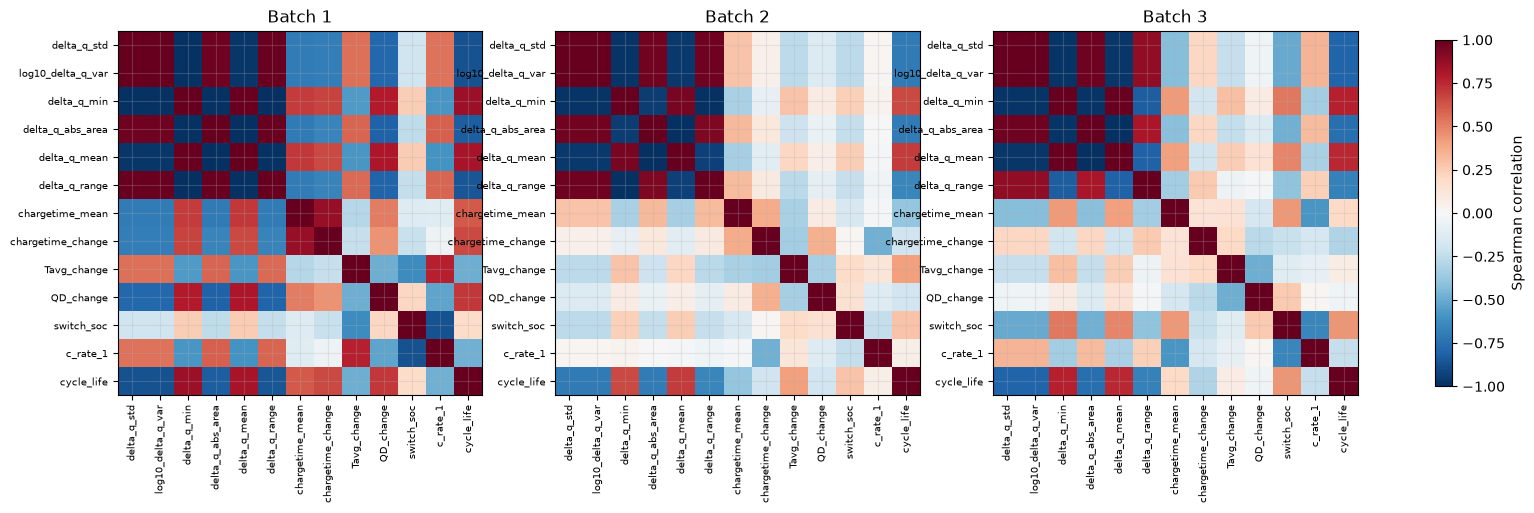

,batch,feature_1,feature_2,spearman_rho
12,Batch 1,delta_q_std,log10_delta_q_var,1.0000
46,Batch 3,delta_q_std,log10_delta_q_var,1.0000
29,Batch 2,delta_q_std,log10_delta_q_var,1.0000
9,Batch 1,delta_q_mean,delta_q_abs_area,-1.0000
14,Batch 1,delta_q_min,delta_q_range,-0.9996
26,Batch 2,delta_q_mean,delta_q_abs_area,-0.9995
43,Batch 3,delta_q_mean,delta_q_abs_area,-0.9993
37,Batch 3,QD_mean,QC_mean,0.9993
31,Batch 2,delta_q_min,delta_q_range,-0.9891
1,Batch 1,QD_change,QC_change,0.9888


In [17]:
top_features = target_corr.nlargest(12, 'mean_abs_rho').index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, batch_name in zip(axes, BATCH_FILES):
    corr = feature_df.loc[feature_df['batch'] == batch_name, top_features + ['cycle_life']].corr(method='spearman')
    image = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    labels = corr.columns.tolist()
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(batch_name)
fig.colorbar(image, ax=axes, label='Spearman correlation', shrink=.75)
plt.show()

multi_rows = []
for batch_name, group in feature_df.groupby('batch'):
    corr = group[feature_columns].corr(method='spearman')
    for i, left in enumerate(corr.columns):
        for right in corr.columns[i + 1:]:
            value = corr.loc[left, right]
            if pd.notna(value) and abs(value) >= .85:
                multi_rows.append({'batch': batch_name, 'feature_1': left, 'feature_2': right, 'spearman_rho': value})
multicollinearity_df = pd.DataFrame(multi_rows)
display(multicollinearity_df.sort_values('spearman_rho', key=abs, ascending=False).head(40))


### Question 5 답변 — 수명과 연관된 초기 신호와 다중공선성

**관찰 — ΔQ 변동성이 가장 강하고 배치 간 방향도 일관된다**

| 초기 피처와 수명의 Spearman ρ | Batch 1 | Batch 2 | Batch 3 |
|---|---:|---:|---:|
| log10_delta_q_var | −0.871 | −0.710 | −0.800 |
| delta_q_std | −0.871 | −0.710 | −0.800 |
| delta_q_min | +0.853 | +0.661 | +0.776 |
| delta_q_abs_area | −0.828 | −0.697 | −0.758 |
| QD_change | +0.706 | −0.193 | −0.041 |
| chargetime_mean | +0.613 | −0.387 | +0.196 |
| Tavg_change | −0.491 | +0.412 | +0.077 |

초기 ΔQ의 표준편차·로그 분산은 각 배치에서 가장 강한 단조 관계를 보인다. 반면 초기 QD·QC 평균과 수명의 상관은 대체로 약하다(QD_mean은 +0.185 / +0.112 / +0.162). QD 변화량·평균 충전시간·평균 온도 변화량 등은 배치에 따라 상관의 부호가 바뀐다.

**해석 — 강한 상관과 독립적인 정보는 다르다**

배치별 Spearman 피처 간 상관에서 `|ρ|≥0.85`인 쌍을 확인했다. 대표적으로 다음 중복이 있다.

- `delta_q_std`와 `log10_delta_q_var`: 세 배치 모두 ρ=+1.000. 같은 곡선의 표준편차와 로그 분산은 일대일 단조 변환이므로 순위 정보가 같다. 이 값만으로 원래 변수 사이의 완전한 선형 종속을 뜻하지는 않지만, 동일한 변동성을 중복 표현한다.
- `delta_q_mean`과 `delta_q_abs_area`: Batch 1=−1.000, Batch 2=−0.9995, Batch 3=−0.9993으로 크기 정보가 거의 겹친다.
- `QD_mean`과 `QC_mean`: Batch 1=+0.9888, Batch 3=+0.9993으로 초기 충·방전 평균 용량의 정보가 겹친다.
- 실제 입력 후보의 `c_rate_1`과 `switch_soc`: Batch 1=−0.8694로 조건 변수 사이에도 높은 상관이 있다.

이 결과는 다중공선성·정보 중복의 신호를 확인한 것이며, VIF나 설계행렬의 조건수로 선형 다중공선성을 정량 검증한 것은 아니다. 수명과의 상관이 높다고 그 피처가 수명의 원인이거나, 다른 피처와 함께 넣었을 때 반드시 추가 예측력을 갖는 것은 아니다.

**질문에 대한 답변**

초기 신호 중 수명과 가장 강하고 배치 간 일관된 단조 관계를 보이는 것은 ΔQ(V)의 변동성이다. 충전시간·QD 변화량·온도 변화량은 배치별 관계 차이가 크다. ΔQ 통계끼리, QD·QC 평균끼리, 일부 충전 조건끼리 높은 상관이 확인되어 정보 중복을 고려해야 한다. 여기의 배치 비교와 평균 절대 상관 순위는 EDA 결과이며, 모델 입력 조합의 최종 선택은 Batch 1 내부 검증에서 별도로 수행한다.


## 9. Batch 간 특성 종합 비교

다섯 질문의 핵심 통계량을 한 표로 모아 Batch 간 차이를 정리한다.

In [18]:
batch_comparison = (
    cells_df.groupby('batch').agg(
        n_cells=('cell_id', 'nunique'),
        cycle_life_mean=('cycle_life', 'mean'),
        cycle_life_median=('cycle_life', 'median'),
        cycle_life_std=('cycle_life', 'std'),
        n_policies=('charging_policy', 'nunique'),
        c_rate_1_mean=('c_rate_1', 'mean'),
    )
    .join(summary_df.groupby('batch').agg(
        initial_QD_median=('initial_QD', 'median'),
        Tavg_median=('Tavg', 'median'),
        IR_median=('IR', 'median'),
    ))
    .join(delta_df.groupby('batch').agg(
        delta_logvar_median=('log10_delta_q_var', 'median'),
        delta_area_median=('delta_q_abs_area', 'median'),
    ))
    .join(knee_df.groupby('batch').agg(
        knee_cycle_median=('knee_cycle', 'median'),
        knee_ratio_median=('knee_ratio', 'median'),
    ))
)
display(batch_comparison.T)


batch,Batch 1,Batch 2,Batch 3
n_cells,46.0000,47.0000,46.0000
cycle_life_mean,844.7174,565.7436,"1,059.6591"
cycle_life_median,858.5000,472.0000,"1,005.5000"
cycle_life_std,184.6292,222.2016,313.8697
n_policies,23.0000,20.0000,8.0000
c_rate_1_mean,5.8783,4.9628,5.2196
initial_QD_median,1.0804,1.0945,1.0675
Tavg_median,33.4707,33.4512,35.5646
IR_median,0.0169,0.0167,0.0155
delta_logvar_median,-3.8509,-3.4947,-4.1987


## 10. EDA에서 확인한 모델 설계 근거

현재까지의 코드는 데이터 로딩, 품질 점검, 시각화, 기술통계, 상관분석 및 탐색용 피처 생성이다. 모델 학습·예측·성능 평가는 수행하지 않았다. 아래에서는 EDA에 근거한 피처 선별과 타깃 정의를 코드로 구현하고, 이후 모델링 절차는 텍스트로 제시한다.

| 확인된 데이터 특성 | 실제 EDA 결과 | 설계에 반영할 내용 |
|---|---|---|
| 독립적인 분석 단위는 셀 | 셀 139개, 수명 확인 셀 129개; Batch 1의 수명 확인 셀은 46개 | 116,722개의 사이클 행을 독립 학습 표본으로 보지 않고 셀당 한 행으로 구성 |
| 배치별 수명 분포 차이 | 중앙값: Batch 1=858.5, Batch 2=472.0, Batch 3=1005.5 | 배치 차이를 고려하고 작은 학습 표본에 맞춰 피처 수와 모델 복잡도 제한 |
| 수명 분포의 오른쪽 꼬리 | 왜도: 0.453 / 1.637 / 1.255, 수명 범위 392~1935 | 로그 수명을 학습 타깃 표현으로 선택; 예측값은 원래 Cycle 단위로 해석할 계획 |
| ΔQ 변동성이 수명과 강한 단조 관계 | log10_delta_q_var와 수명의 Spearman rho: -0.871 / -0.710 / -0.800 | 초기 열화 신호를 대표하는 핵심 피처로 선정; 상관이 예측 성능이나 인과관계를 증명하는 것은 아님 |
| ΔQ 피처끼리 정보가 겹침 | delta_q_std와 log10_delta_q_var의 rho=1.000 (세 배치); 나머지 ΔQ 피처도 강한 상관 | ΔQ 피처 6개를 모두 넣지 않고 대표 변수 하나로 시작 |
| 충전시간·조건 관계의 배치별 차이 | chargetime_mean rho: +0.613 / -0.387 / +0.196; c_rate_1 rho: -0.483 / +0.055 / -0.229 | 물리적으로 의미 있는 조건 변수는 확장 후보로 두되 성능 개선을 미리 단정하지 않음 |
| 클래스 구성 차이 | Batch 1의 수명 500 미만 셀 0개; Batch 2에서는 71.8% | 현재 3개 수명 그룹을 그대로 분류 모델의 타깃으로 사용하기 어려움 |
| 일부 수명 미확인 | Batch 2=8개, Batch 3=2개 | 타깃을 임의로 채우지 않고 지도학습용 테이블에서만 제외 |


## 11. 모델 입력 후보 선정 (Feature Selection)

예측 시점을 **Cycle 100 측정 완료 직후**로 정의한다. 입력은 충전 조건과 Cycle 1~100에서 관측 가능한 값으로만 구성한다. Question 3에서 ΔQ(V) 통계 피처, Question 4에서 충전 조건, Question 5에서 초기 평균·변화량을 탐색용으로 생성했다. 이 절에서는 피처를 다시 계산하지 않고, EDA 결과와 도메인 의미를 바탕으로 모델 입력 후보를 선별한다. 피처 생성과 모델 입력 후보 선정을 구분하며, 기존 A/B/C 조합과 계산식은 그대로 유지한다.

| 피처 | 계산·의미 | 선정 이유와 사용 범위 |
|---|---|---|
| log10_delta_q_var | Cycle 100−10의 ΔQ(V)를 공통 전압축에 정렬한 후 표본분산의 log10 | 핵심 선정: 수명과 강한 관계, 분산의 스케일을 압축하며 ΔQ 피처 중 대표 하나로 사용 |
| c_rate_1 | 충전 정책에서 추출한 첫 단계 C-rate | 확장 후보: Batch 1 rho=-0.483, 충전 강도 정보; 배치 간 관계가 일정하지 않아 추가 효과를 추후 확인 |
| switch_soc | 첫 단계에서 두 번째 단계로 전환하는 SOC (%) | 확장 후보: rho=+0.185 / +0.288 / +0.443; 전환 조건 정보, 단일 상관은 약함 |
| chargetime_mean | Cycle 1~100 충전시간의 평균 (원본 단위 유지) | 추가 비교 후보: Batch 1 rho=+0.613; 정책 변수와의 중복 및 배치별 부호 변화를 확인해야 함 |

**비교할 피처 조합:** A=핵심 1개, B=A+충전 조건 2개, C=B+초기 평균 충전시간. 현재 선정은 설계 후보이며, 최종 조합은 이후 Batch 1 내부 검증에서 결정한다. 전체 배치의 평균 상관 순위로 자동 선정하지 않는다.

**첫 설계에서 제외:** delta_q_std/min/range/mean/abs_area는 대표 ΔQ 피처와 중복되어 제외한다. QD_mean/QC_mean은 수명과의 단일 상관이 상대적으로 약하고 서로 중복된다. QD_change, chargetime_change, Tavg_change는 배치별 상관 부호가 달라 보류한다. 온도·IR 등 나머지 초기 신호는 추후 추가 효과를 확인할 후보로 남긴다.

**입력 금지:** cycle_life, log10_cycle_life, 수명으로 만든 life_group, 전체 기록 길이 n_cycles, knee_cycle/knee_ratio, 마지막 Cycle/QD/유지율, Cycle 100 이후 관측값. 이들은 타깃 또는 미래 정보다. batch와 cell_id도 입력에서 제외하고 데이터 구분에만 사용한다. 충전 정책 문자열은 수치형 C-rate/SOC로 표현하므로 원문 자체를 추가 인코딩하지 않는다.

In [19]:
FEATURE_SETS = {
    'A_core': ['log10_delta_q_var'],
    'B_charging_conditions': ['log10_delta_q_var', 'c_rate_1', 'switch_soc'],
    'C_charging_time': ['log10_delta_q_var', 'c_rate_1', 'switch_soc', 'chargetime_mean'],
}
SELECTED_CANDIDATES = FEATURE_SETS['C_charging_time']
selection_reasons = {
    'log10_delta_q_var': '핵심: 강한 수명 상관, ΔQ 대표 변수',
    'c_rate_1': '확장: 충전 강도, 배치별 관계 차이 확인 필요',
    'switch_soc': '확장: 충전 전환 조건, 단일 상관은 약함',
    'chargetime_mean': '추가 비교: 초기 충전시간, 배치별 부호 차이',
}
feature_selection_evidence = target_corr.loc[SELECTED_CANDIDATES, list(BATCH_FILES)].copy()
feature_selection_evidence['missing_rate_percent'] = (
    feature_df[SELECTED_CANDIDATES].replace([np.inf, -np.inf], np.nan).isna().mean() * 100
)
feature_selection_evidence['reason'] = feature_selection_evidence.index.map(selection_reasons)
display(feature_selection_evidence)
display(pd.DataFrame([
    {'feature_set': name, 'n_features': len(columns), 'features': ', '.join(columns)}
    for name, columns in FEATURE_SETS.items()
]))
print('학습 배치(Batch 1) 후보 변수 간 Spearman 상관: 조건·시간 정보 중복 확인')
display(feature_df.loc[feature_df['batch'] == 'Batch 1', SELECTED_CANDIDATES].corr(method='spearman'))


,Batch 1,Batch 2,Batch 3,missing_rate_percent,reason
log10_delta_q_var,-0.8712,-0.7104,-0.7999,0.0000,"핵심: 강한 수명 상관, ΔQ 대표 변수"
c_rate_1,-0.4827,0.0551,-0.2289,2.8777,"확장: 충전 강도, 배치별 관계 차이 확인 필요"
switch_soc,0.1852,0.2878,0.4433,2.8777,"확장: 충전 전환 조건, 단일 상관은 약함"
chargetime_mean,0.6131,-0.3868,0.1964,0.0000,"추가 비교: 초기 충전시간, 배치별 부호 차이"


,feature_set,n_features,features
0,A_core,1,log10_delta_q_var
1,B_charging_conditions,3,"log10_delta_q_var, c_rate_1, switch_soc"
2,C_charging_time,4,"log10_delta_q_var, c_rate_1, switch_soc, charg..."


학습 배치(Batch 1) 후보 변수 간 Spearman 상관: 조건·시간 정보 중복 확인


,log10_delta_q_var,c_rate_1,switch_soc,chargetime_mean
log10_delta_q_var,1.0000,0.5396,-0.1981,-0.6971
c_rate_1,0.5396,1.0000,-0.8694,-0.1190
switch_soc,-0.1981,-0.8694,1.0000,-0.1285
chargetime_mean,-0.6971,-0.1190,-0.1285,1.0000


## 12. Regression 선택 및 Target Variable 정의

**선택: Regression (회귀).** 목표는 초기 100사이클을 관측한 셀의 전체 수명을 Cycle 수로 추정하는 것이다. 원본 cycle_life는 수치형 수명이고, 500/1000 같은 분류 경계에는 아직 별도의 운영 근거가 없다. Batch 1에는 500 미만 클래스가 없으며 1000 초과 셀도 약 21.7%이므로, 현재 3개 구간을 그대로 학습하는 분류보다 수명을 직접 예측하는 회귀를 선택한다.

- **원래 타깃:** 제공된 cycle_life, 단위는 Cycle. 마지막으로 관측한 Cycle과 같은 값이라고 가정하지 않는다. EDA의 QD/초기QD=0.8 교차점으로 원본 라벨을 재정의하지 않는다.
- **학습에 사용할 타깃 표현:** log10_cycle_life = log10(cycle_life). 수명 분포의 오른쪽 꼬리와 값의 스케일 차이를 줄이기 위한 설계 선택이다. 로그 변환이 성능 향상을 보장하지는 않는다.
- **향후 해석:** 예측된 로그 수명에 10의 거듭제곱을 적용해 Cycle 단위로 되돌리고, 원래 단위의 오차를 확인할 계획이다. 총 수명을 예측하며, Cycle 100에서의 잔여 수명  cycle_life−100은 이번 타깃으로 사용하지 않는다.
- **분석 단위:** 셀당 한 행. Cycle 1~100이 관측되고 양수의 수명 라벨이 있는 셀만 지도학습 준비 테이블에 포함한다. 수명 미확인 셀의 측정 데이터는 기존 EDA 테이블에 유지한다.

In [20]:
TARGET_COLUMN = 'cycle_life'
TARGET_TRANSFORMED_COLUMN = 'log10_cycle_life'

# 초기 100사이클의 관측 여부를 확인한다.
early_availability = (
    summary_df.loc[summary_df['cycle'].between(1, 100)]
    .groupby(['batch', 'cell_id'])['cycle'].nunique().rename('n_early_cycles')
)
design_data = feature_df[['batch', 'cell_id', TARGET_COLUMN] + SELECTED_CANDIDATES].copy()
design_data[SELECTED_CANDIDATES] = design_data[SELECTED_CANDIDATES].replace([np.inf, -np.inf], np.nan)
design_data = design_data.join(early_availability, on=['batch', 'cell_id'])
eligible = (
    np.isfinite(design_data[TARGET_COLUMN]) & (design_data[TARGET_COLUMN] > 0)
    & (design_data['n_early_cycles'] == 100)
)
prepared_features_target = design_data.loc[eligible].drop(columns='n_early_cycles').copy()
prepared_features_target[TARGET_TRANSFORMED_COLUMN] = np.log10(prepared_features_target[TARGET_COLUMN])

target_preparation_summary = design_data.groupby('batch').agg(
    total_cells=('cell_id', 'size'), known_target=(TARGET_COLUMN, 'count'),
)
target_preparation_summary['eligible_cells'] = (
    prepared_features_target.groupby('batch').size().reindex(target_preparation_summary.index, fill_value=0)
)
target_preparation_summary['excluded_cells'] = (
    target_preparation_summary['total_cells'] - target_preparation_summary['eligible_cells']
)
display(target_preparation_summary)
print('선정된 피처 후보와 회귀 타깃 (스케일링·결측치 대체 전)')
display(prepared_features_target.head(10))
print('전체 준비 테이블:', prepared_features_target.shape)
print('원래 타깃:', TARGET_COLUMN, '/ 로그 표현:', TARGET_TRANSFORMED_COLUMN)


,total_cells,known_target,eligible_cells,excluded_cells
batch,,,,
Batch 1,46,46,46,0
Batch 2,47,39,39,8
Batch 3,46,44,44,2


선정된 피처 후보와 회귀 타깃 (스케일링·결측치 대체 전)


,batch,cell_id,cycle_life,log10_delta_q_var,c_rate_1,switch_soc,chargetime_mean,log10_cycle_life
0,Batch 1,Batch1_cell_000,"1,190.0000",-5.0144,3.6000,80.0000,13.2504,3.0755
1,Batch 1,Batch1_cell_001,"1,179.0000",-5.0137,3.6000,80.0000,13.2409,3.0715
2,Batch 1,Batch1_cell_002,"1,177.0000",-4.7366,3.6000,80.0000,13.2451,3.0708
3,Batch 1,Batch1_cell_003,"1,226.0000",-4.4423,4.0000,80.0000,11.9327,3.0885
4,Batch 1,Batch1_cell_004,"1,227.0000",-4.6474,4.0000,80.0000,11.9328,3.0888
5,Batch 1,Batch1_cell_005,"1,074.0000",-4.1787,4.4000,80.0000,14.9250,3.0310
6,Batch 1,Batch1_cell_006,636.0000,-3.7686,4.8000,80.0000,9.9444,2.8035
7,Batch 1,Batch1_cell_007,870.0000,-3.8132,4.8000,80.0000,9.9437,2.9395
8,Batch 1,Batch1_cell_008,879.0000,-4.0009,5.4000,40.0000,11.1312,2.9440
9,Batch 1,Batch1_cell_009,"1,054.0000",-4.0591,5.4000,40.0000,11.1294,3.0228


전체 준비 테이블: (129, 8)
원래 타깃: cycle_life / 로그 표현: log10_cycle_life


## 13. 확인된 데이터 특성 기반 Modeling Strategy

### 데이터 처리 전략
1. Batch 1은 학습·내부 검증용, Batch 2·3은 배치 간 일반화 비교용으로 구분한다. 같은 셀의 사이클이 서로 다른 학습/검증 영역에 들어가지 않도록 셀 단위 테이블을 사용한다.
2. Batch 1의 46개 셀은 작으므로 내부 검증에서 충전 정책을 그룹으로 묶은 5-fold GroupKFold를 우선 검토한다. 같은 정책 셀을 한 폴드에 모아 미관측 정책에 대한 일반화를 확인한다. 정책 그룹 수 및 폴드별 수명 분포도 함께 점검한다. 시간 순서가 핵심인 운영 예측을 검증할 때는 확인된 실험 시점에 따라 순서대로 분할한다.
3. 결측 타깃은 대체하지 않는다. 입력 결측치는 원인을 확인하고 필요한 경우 훈련 폴드의 중앙값으로만 대체한다. 현재 선정 피처의 결측률은 위 근거표로 확인한다. 무한값은 결측값으로 취급한다.
4. 선형 모델은 중앙값 대체와 StandardScaler를 파이프라인에 넣고, 각 훈련 폴드에서만 fit한다. 트리 모델은 스케일링 없이 비교한다. 피처 조합 선택·하이퍼파라미터 조정도 내부 검증에서 수행한다.
5. 수명 자체의 극단값은 정상 장수명일 수 있으므로 박스플롯 이상치라는 이유만으로 제거하지 않는다. QD/충전시간 등 측정 스파이크는 원본 및 실험 조건을 먼저 확인한다. 데이터로 정하는 제거 기준이나 클리핑 경계는 훈련 데이터에서만 결정한다.
6. random_state=42를 무작위 분할·샘플링·해당 모델에 적용한다. 학습 단계에서 라이브러리 버전, 원본 파일 정보, 사용 셀 목록, 선택 피처 및 실험 설정을 기록한다.

### 실제 모델 개발에 사용할 후보 모델과 선정 이유

초기 열화 신호와 충전 조건을 입력으로 사용해 수명을 예측하는 세 가지 회귀 모델을 후보로 선정한다. 이 단계에서는 후보와 선정 근거만 제시하며 모델 학습·예측·성능 평가는 수행하지 않는다.

| 역할 | 후보 | 데이터 특성과 연결한 이유 |
|---|---|---|
| 단일 피처의 선형 관계 확인 | 피처 A의 LinearRegression | Batch 1에서 log10_delta_q_var와 수명의 Spearman rho=-0.871로 강한 단조 관계가 확인되었다. 핵심 피처 하나와 로그 수명의 관계를 단순한 선형식으로 어디까지 설명할 수 있는지 확인한다. 단조 관계가 선형 관계를 보장하지 않으므로 이후 잔차를 점검한다. |
| 규제를 적용한 선형 모델의 우선 후보 | 피처 A/B/C의 Ridge Regression | Batch 1의 독립 표본은 46개 셀로 작고, 확장 후보 c_rate_1과 switch_soc의 Spearman rho=-0.869로 정보 중복이 있다. L2 규제로 계수 크기를 제한해 추정의 변동을 줄이는 접근을 비교한다. 규제가 피처 간 상관 자체를 없애거나 성능 개선을 보장하는 것은 아니다. [Ridge 공식 설명](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) |
| 비선형 관계·상호작용 비교 | 피처 A/B/C의 얕은 RandomForestRegressor | 충전 정책별 수명 차이가 있고 첫 단계 C-rate 하나로 수명 차이를 모두 설명할 수 없어, ΔQ 신호와 충전 조건의 비선형 관계 및 상호작용이 추가 예측력을 갖는지 비교한다. 작은 표본의 과적합 위험을 고려해 max_depth와 min_samples_leaf로 복잡도를 제한한다. [Random Forest 공식 설명](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) |

정형 데이터이고 Batch 1은 46개 셀뿐이므로 딥러닝을 첫 후보로 두지 않는다. LinearRegression으로 단순 선형 관계, Ridge로 규제의 효과, Random Forest로 비선형 관계의 추가 효과를 비교한다. 기존 A/B/C 피처 조합은 유지하며, 후보 중 최종 모델은 아직 정하지 않는다. 이후 Batch 1 내부 검증에서 피처 조합·규제 강도·트리 복잡도를 선택하고, 설정을 고정한 뒤 Batch 2·3에 적용한다. 일반적인 회귀 트리의 예측값은 잎 노드의 훈련 타깃 평균이므로 Random Forest는 훈련 수명 범위 밖 예측에 한계가 있다. 이것이 선형 모델을 함께 검토하는 이유이며, 선형 모델의 예측이 정확하다는 뜻은 아니다.